In [38]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
import matplotlib.pyplot as plt

CSV_PATH = "raw_wholesale_customers.csv"
OUT_PATH = "segmented_wholesale_customers.csv"
FEATURES = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]
RANDOM_STATE = 42
K = 5

In [25]:
# 1) Load Dataset

df = pd.read_csv(CSV_PATH)
print("\n=== 1) INITIAL SNAPSHOT ===")
print(df.head())
print("\n=== DATA INFO ===")
print(df.info())


=== 1) INITIAL SNAPSHOT ===
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185

=== DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergent

In [26]:
# 2) Select Features + IQR Cap
X = df[FEATURES].copy()

def iqr_fun(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return lower, upper

low_fresh,   high_fresh   = iqr_fun(X["Fresh"])
low_milk,    high_milk    = iqr_fun(X["Milk"])
low_grocery, high_grocery = iqr_fun(X["Grocery"])
low_frozen,  high_frozen  = iqr_fun(X["Frozen"])
low_det,     high_det     = iqr_fun(X["Detergents_Paper"])
low_deli,    high_deli    = iqr_fun(X["Delicassen"])

X["Fresh"]            = X["Fresh"].clip(lower=low_fresh,  upper=high_fresh)
X["Milk"]             = X["Milk"].clip(lower=low_milk,    upper=high_milk)
X["Grocery"]          = X["Grocery"].clip(lower=low_grocery, upper=high_grocery)
X["Frozen"]           = X["Frozen"].clip(lower=low_frozen,  upper=high_frozen)
X["Detergents_Paper"] = X["Detergents_Paper"].clip(lower=low_det, upper=high_det)
X["Delicassen"]       = X["Delicassen"].clip(lower=low_deli, upper=high_deli)

df[FEATURES] = X

print("\n=== 2) FEATURES HEAD (after IQR cap) ===")
print(X.head())


=== 2) FEATURES HEAD (after IQR cap) ===
     Fresh    Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0  12669.0  9656.0   7561.0   214.0            2674.0     1338.00
1   7057.0  9810.0   9568.0  1762.0            3293.0     1776.00
2   6353.0  8808.0   7684.0  2405.0            3516.0     3938.25
3  13265.0  1196.0   4221.0  6404.0             507.0     1788.00
4  22615.0  5410.0   7198.0  3915.0            1777.0     3938.25


In [27]:
# 3) Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\n=== 3) SCALED FEATURES ===")
print("Scaled shape:", X_scaled.shape)


=== 3) SCALED FEATURES ===
Scaled shape: (440, 6)


In [33]:
print("===ELBOW METHOD (SSE per k) ===")
for k in range(1, 11):
    km = KMeans(n_clusters=k, n_init="auto", random_state=RANDOM_STATE)
    km.fit(X_scaled)
    print(f"k={k} → SSE={km.inertia_:.2f}")

===ELBOW METHOD (SSE per k) ===
k=1 → SSE=2640.00
k=2 → SSE=1728.19
k=3 → SSE=1363.45
k=4 → SSE=1202.41
k=5 → SSE=1070.15
k=6 → SSE=964.76
k=7 → SSE=921.14
k=8 → SSE=776.63
k=9 → SSE=726.88
k=10 → SSE=707.41


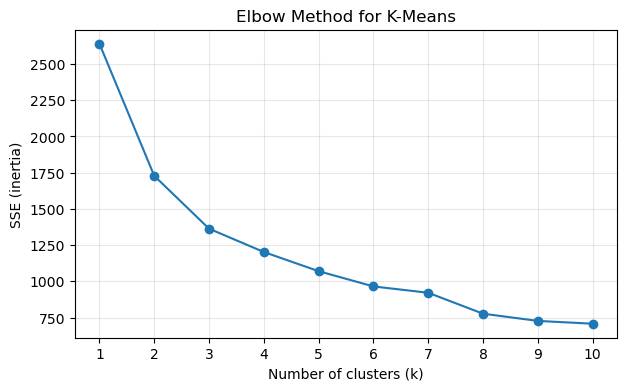

In [37]:
plt.figure(figsize=(7, 4))
plt.plot(list(sse.keys()), list(sse.values()), marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("SSE (inertia)")
plt.title("Elbow Method for K-Means")
plt.xticks(range(1, 11))
plt.grid(alpha=0.3)
plt.show()


=== 5) SAMPLE WITH K-MEANS CLUSTERS ===
   Channel  Region    Fresh    Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669.0  9656.0   7561.0   214.0            2674.0   
1        2       3   7057.0  9810.0   9568.0  1762.0            3293.0   
2        2       3   6353.0  8808.0   7684.0  2405.0            3516.0   
3        1       3  13265.0  1196.0   4221.0  6404.0             507.0   
4        2       3  22615.0  5410.0   7198.0  3915.0            1777.0   

   Delicassen  KMeans_Cluster  
0     1338.00               0  
1     1776.00               0  
2     3938.25               0  
3     1788.00               3  
4     3938.25               3  


In [41]:
# 6) Evaluate K-Means
# ------------------------------------------------------------------------------
sil_km = silhouette_score(X_scaled, df["KMeans_Cluster"])
db_km = davies_bouldin_score(X_scaled, df["KMeans_Cluster"])

print("\n=== 6) K-MEANS EVALUATION ===")
print(f"K-Means Silhouette Score : {sil_km:.4f} (closer to +1 is better)")
print(f"K-Means Davies–Bouldin   : {db_km:.4f} (lower is better)")

# Cluster centers back to original units
centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers_original, columns=FEATURES)
centers_df.index.name = "Cluster"

print("\n=== CLUSTER CENTERS (Original Units) ===")
print(centers_df.round(2))


=== 6) K-MEANS EVALUATION ===
K-Means Silhouette Score : 0.2831 (closer to +1 is better)
K-Means Davies–Bouldin   : 1.2701 (lower is better)

=== CLUSTER CENTERS (Original Units) ===
            Fresh      Milk   Grocery   Frozen  Detergents_Paper  Delicassen
Cluster                                                                     
0         9202.67   6833.30   9104.12  1326.16           3280.12     1871.76
1         8376.23   2150.65   3160.63  1646.33            779.25      674.02
2        17461.54  13805.60  17524.12  4120.57           5460.56     3583.64
3        22346.70   3409.14   3969.33  5819.60            583.07     1566.95
4         4916.98  10768.85  18350.13  1212.37           7780.02      981.37


 7) Research & Train a Second Clustering Algorithm
### 7) Research & Train a Second Clustering Algorithm: Agglomerative Hierarchical Clustering

* **Algorithm Chosen:** Agglomerative Hierarchical Clustering
* **Why it fits wholesale customer segmentation:** Unlike K-Means, which assumes spherical clusters and relies heavily on predefined geometric shapes, Agglomerative Clustering builds a bottom-up hierarchy based on proximity. This is exceptionally well-suited for wholesale customer segmentation because business clients naturally exhibit nested sub-group behaviors (e.g., small budget restaurants vs. massive hotel chains). It allows the model to identify organic spending relationships and multi-layered customer tiers without forcing data points into fixed, rigid cluster sizes from the start.
* **Source used for research:** Scikit-Learn Official Documentation (`sklearn.cluster.AgglomerativeClustering`). URL: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html

In [48]:
agg = AgglomerativeClustering(n_clusters=5)
df["Agg_Cluster"] = agg.fit_predict(X_scaled)

print("\n=== 7) SECOND ALGORITHM (AGGLOMERATIVE) TRAINED ===")
print(df.head())


=== 7) SECOND ALGORITHM (AGGLOMERATIVE) TRAINED ===
   Channel  Region    Fresh    Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669.0  9656.0   7561.0   214.0            2674.0   
1        2       3   7057.0  9810.0   9568.0  1762.0            3293.0   
2        2       3   6353.0  8808.0   7684.0  2405.0            3516.0   
3        1       3  13265.0  1196.0   4221.0  6404.0             507.0   
4        2       3  22615.0  5410.0   7198.0  3915.0            1777.0   

   Delicassen  KMeans_Cluster  Agg_Cluster  
0     1338.00               0            4  
1     1776.00               0            4  
2     3938.25               0            0  
3     1788.00               3            3  
4     3938.25               3            0  


In [50]:
# 8) Compare Methods
sil_agg = silhouette_score(X_scaled, df["Agg_Cluster"])

print("\n=== 8) ALGORITHM COMPARISON ===")
print(f"K-Means Silhouette Score       : {sil_km:.4f}")
print(f"Agglomerative Silhouette Score : {sil_agg:.4f}")

if sil_km > sil_agg:
    print("Conclusion: K-Means produced better-separated clusters.")
else:
    print("Conclusion: Agglomerative Clustering produced better-separated clusters.")


=== 8) ALGORITHM COMPARISON ===
K-Means Silhouette Score       : 0.2831
Agglomerative Silhouette Score : 0.2185
Conclusion: K-Means produced better-separated clusters.


In [52]:
#9) Sanity Check (3 clients)
sample_idx = [0, 1, 2]
sanity_cols = ["Channel", "Region"] + FEATURES + ["KMeans_Cluster", "Agg_Cluster"]
print("\n=== 9) SANITY CHECK (3 CLIENTS) ===")
print(df.loc[sample_idx, sanity_cols])


=== 9) SANITY CHECK (3 CLIENTS) ===
   Channel  Region    Fresh    Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669.0  9656.0   7561.0   214.0            2674.0   
1        2       3   7057.0  9810.0   9568.0  1762.0            3293.0   
2        2       3   6353.0  8808.0   7684.0  2405.0            3516.0   

   Delicassen  KMeans_Cluster  Agg_Cluster  
0     1338.00               0            4  
1     1776.00               0            4  
2     3938.25               0            0  


In [ ]:
df_final = df.copy()
df_final["Cluster"] = df_final["KMeans_Cluster"]

df_final = df_final.drop(columns=["KMeans_Cluster", "Agg_Cluster"])

df_final.to_csv(OUT_PATH, index=False)
print(f"\n=== 10) OUTPUT SAVED ===")
print(f"Saved clustered dataset successfully → {OUT_PATH}")


=== 10) OUTPUT SAVED ===
Saved clustered dataset successfully → segmented_wholesale_customers.csv
